## Cell 1: 라이브러리 import 및 환경 설정

In [1]:
#
# [이 셀의 역할]
# 프로젝트에 필요한 모든 라이브러리를 불러오고,
# GPU 사용 가능 여부를 확인하며, 난수 시드를 고정하여
# 코드 실행마다 결과가 동일하게 나오도록 환경을 세팅합니다.
#
# [주요 라이브러리 설명]
# - torch        : 딥러닝 프레임워크. 모델 정의·학습·추론에 사용
# - torch.nn     : 신경망 레이어(Embedding, Linear, LayerNorm 등) 모음
# - gensim       : Word2Vec 학습에 사용. 단어 간 유사도 계산 가능
# - mecab        : 한국어 형태소 분석기. "놀러가고" → ["놀", "러", "가", "고"]
# - nltk         : BLEU 점수 계산 도구 포함
# - tqdm         : 학습 진행률을 시각적으로 보여주는 진행 바

import os, re, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import LambdaLR

from gensim.models import Word2Vec
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ── MeCab 로드 ──────────────────────────────────────────────
# MeCab(python-mecab-ko)을 우선 시도하고,
# 설치가 안 됐으면 글자 단위 분리로 대체합니다.
# MeCab은 "피곤하다" → ["피곤", "하", "다"] 처럼 의미 단위로 분리해
# 모델이 더 잘 학습할 수 있게 도와줍니다.
try:
    from mecab import MeCab
    _mecab = MeCab()
    def tokenize(text):
        """MeCab 형태소 분석: 문장을 의미 단위 토큰 리스트로 변환"""
        return _mecab.morphs(str(text))
    print("MeCab 로드 성공")
except Exception as e:
    print(f"MeCab 오류: {e} → 음절 단위 폴백")
    def tokenize(text):
        """MeCab 없을 때 대체: 공백 제거 후 글자 단위 분리"""
        return list(str(text).replace(" ", ""))

# ── 재현성(Reproducibility) 고정 ────────────────────────────
# 딥러닝은 내부적으로 난수를 많이 사용합니다.
# 시드(seed)를 고정하면 실행할 때마다 동일한 결과가 나와
# 실험 비교와 디버깅이 쉬워집니다.
SEED = 42
random.seed(SEED)        # Python 기본 random 모듈
np.random.seed(SEED)     # NumPy 난수
torch.manual_seed(SEED)  # PyTorch CPU 연산
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)  # PyTorch GPU 연산

# ── GPU 자동 감지 ────────────────────────────────────────────
# RTX 3070이 있으면 'cuda', 없으면 'cpu'로 자동 설정됩니다.
# GPU는 수천 개의 코어가 행렬 연산을 동시에 처리하므로
# CPU보다 딥러닝 학습이 훨씬 빠릅니다 (보통 10~50배).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")
if device.type == "cuda":
    print(f"GPU 모델: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


MeCab 로드 성공
사용 장치: cuda
GPU 모델: NVIDIA GeForce RTX 3070 Ti
VRAM: 8.6 GB


## Cell 2: 하이퍼파라미터 설정

In [2]:
#
# [이 셀의 역할]
# 모델 구조와 학습 방법을 결정하는 핵심 숫자들을 한곳에 모아 놓습니다.
# 나중에 실험할 때 이 셀만 수정하면 되어 관리가 편합니다.
#
# [특수 토큰이란?]
# Transformer는 텍스트 외에 특별한 의미를 가진 토큰을 사용합니다.
#   <pad>   : 짧은 문장을 일정 길이로 맞출 때 채우는 빈칸 (인덱스 0)
#   <start> : 디코더가 답변 생성을 시작하는 신호 (인덱스 1)
#   <end>   : 답변이 끝났다는 신호 (인덱스 2)
#   <unk>   : 학습 때 못 봤던 단어를 대체 (인덱스 3)

PAD_IDX, START_IDX, END_IDX, UNK_IDX = 0, 1, 2, 3

# ── 데이터 관련 파라미터 ─────────────────────────────────────
# MAX_LEN=50 : 입력/출력 문장의 최대 토큰 수.
#              한국어 일상 대화는 보통 10~30 토큰이므로 50이면 충분합니다.
#              너무 크면 메모리가 많이 필요하고 학습이 느려집니다.
# BATCH_SIZE=64 : 한 번에 처리할 문장 쌍의 수.
#              RTX 3070(8GB VRAM)에서 64는 안정적인 값입니다.
# TARGET_AUG=30000 : 증강 후 목표 데이터 수 (평가 기준 충족용).
MAX_LEN    = 50
BATCH_SIZE = 64
TARGET_AUG = 30000

# ── 모델 구조 파라미터 ──────────────────────────────────────
# D_MODEL=256  : 각 토큰을 표현하는 벡터의 차원 수.
#                클수록 표현력이 높지만 학습이 느리고 과적합 위험 증가.
#                30,000쌍 데이터에는 256이 적절합니다 (384는 과적합 위험).
# N_HEADS=8    : 어텐션 헤드 수. 256 / 8 = 헤드당 32차원.
#                각 헤드가 문장의 서로 다른 관계(주어-서술어, 시제 등)를 학습.
# N_LAYERS=2   : 인코더·디코더 각각 2개 레이어. 깊을수록 복잡한 패턴 학습 가능.
# D_FF=512     : FeedForward 내부 차원. 보통 D_MODEL의 2~4배로 설정.
# DROPOUT=0.1  : 학습 중 무작위로 10% 뉴런을 끄는 정규화 기법.
#                이전 실패 설정(0.3)은 너무 높아 학습 자체가 안 됐습니다.
D_MODEL  = 256
N_HEADS  = 8
N_LAYERS = 2
D_FF     = 512
DROPOUT  = 0.1

# ── 학습 파라미터 ────────────────────────────────────────────
# EPOCHS=30       : 전체 데이터를 30번 반복 학습.
#                   30,000쌍 데이터는 30 에폭이면 충분히 수렴합니다.
# WARMUP_STEPS=4000 : 학습 초반에 학습률을 천천히 올리는 구간.
#                   초기에 학습률이 너무 높으면 모델 가중치가 불안정해집니다.
#                   이전 실패(1500)는 너무 짧아 초기 학습이 불안정했습니다.
EPOCHS       = 30
WARMUP_STEPS = 4000

# ── 파일 경로 ────────────────────────────────────────────────
DATA_PATH  = r"C:\AI_study\chatbot\ChatbotData.csv"
MODEL_PATH = r"C:\AI_study\chatbot\best_model.pt"
W2V_PATH   = r"C:\AI_study\chatbot\w2v.model"

print(f"모델 구조  : D_MODEL={D_MODEL}, N_HEADS={N_HEADS}, N_LAYERS={N_LAYERS}, D_FF={D_FF}")
print(f"학습 설정  : DROPOUT={DROPOUT}, EPOCHS={EPOCHS}, WARMUP={WARMUP_STEPS}")
print(f"데이터 설정: MAX_LEN={MAX_LEN}, BATCH_SIZE={BATCH_SIZE}, 목표={TARGET_AUG}쌍")


모델 구조  : D_MODEL=256, N_HEADS=8, N_LAYERS=2, D_FF=512
학습 설정  : DROPOUT=0.1, EPOCHS=30, WARMUP=4000
데이터 설정: MAX_LEN=50, BATCH_SIZE=64, 목표=30000쌍


## Cell 3: 데이터 로드 및 전처리

In [3]:
#
# [이 셀의 역할]
# ChatbotData.csv를 읽어서 모델 학습에 불필요한 문자를 제거하고,
# 너무 짧거나 긴 문장을 필터링하여 품질 좋은 데이터만 남깁니다.
#
# [전처리가 필요한 이유]
# 원본 데이터에는 특수문자(★, ♥, 이모지 등)나 HTML 태그가 섞여 있을 수 있습니다.
# 이런 노이즈는 vocab(어휘 사전) 크기를 불필요하게 늘리고 학습을 방해합니다.
# 한글·영문·숫자·기본 문장부호만 남겨 깨끗한 데이터를 만듭니다.

def preprocess_text(text):
    """
    텍스트 정제 함수.
    1단계: 허용 문자(한글·영문·숫자·.,!?)만 남기고 나머지는 공백으로 교체
    2단계: 연속된 공백을 하나로 줄이고 앞뒤 공백 제거
    """
    text = str(text).strip()
    # 정규표현식: [^ ... ] = 괄호 안에 없는 문자를 공백으로 교체
    # 가-힣 = 모든 한글, \s = 공백
    text = re.sub(r"[^가-힣a-zA-Z0-9\s.,!?]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# CSV 파일 로드
# ChatbotData.csv 구조: Q(질문), A(답변), label(감정 레이블)
df = pd.read_csv(DATA_PATH)
print(f"원본 데이터: {len(df)}행")
print(df.head(3))

# 컬럼명 확인 및 정리
# 파일에 따라 컬럼명이 다를 수 있어서 Q가 없으면 강제로 이름 지정
if "Q" not in df.columns:
    df.columns = ["Q", "A", "label"][: len(df.columns)]

df = df[["Q", "A"]].copy()          # Q, A 컬럼만 사용
df["Q"] = df["Q"].apply(preprocess_text)
df["A"] = df["A"].apply(preprocess_text)

# 품질 필터링
df = df.dropna()  # 빈 값(NaN) 제거
# 글자 수 기준 필터링: 너무 짧으면 학습 의미 없고, 너무 길면 MAX_LEN에서 잘림
df = df[(df["Q"].str.len() >= 2) & (df["Q"].str.len() <= 150)]
df = df[(df["A"].str.len() >= 2) & (df["A"].str.len() <= 150)]
# 동일한 질문이 여러 번 나오면 한 개만 유지 (중복 제거)
df = df.drop_duplicates(subset=["Q"]).reset_index(drop=True)
print(f"전처리 후 : {len(df)}쌍")
print(f"예시 Q: {df['Q'][0]}")
print(f"예시 A: {df['A'][0]}")


원본 데이터: 11823행
              Q            A  label
0        12시 땡!   하루가 또 가네요.      0
1   1지망 학교 떨어졌어    위로해 드립니다.      0
2  3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
전처리 후 : 11648쌍
예시 Q: 12시 땡!
예시 A: 하루가 또 가네요.


## Cell 4: MeCab 토큰화 + Word2Vec 학습용 코퍼스 구축

In [4]:
#
# [이 셀의 역할]
# 모든 Q·A 문장을 MeCab으로 형태소 분석하여
# Word2Vec 학습에 사용할 코퍼스(문장 모음)를 만듭니다.
#
# [형태소 분석이 필요한 이유]
# 한국어는 어미가 변화하는 교착어입니다.
# "먹다", "먹어", "먹었다", "먹고"는 모두 "먹"이라는 동일한 어근을 가집니다.
# 형태소 분석으로 "먹+다", "먹+어", "먹+었+다" 로 분리하면
# 모델이 단어 간 관계를 더 쉽게 학습할 수 있습니다.
#
# [코퍼스(corpus)란?]
# Word2Vec을 학습시키기 위한 문장 리스트입니다.
# 예: [["오늘", "날씨", "좋", "다"], ["피곤", "하", "다"], ...]

def build_corpus(df):
    """
    DataFrame의 Q·A 문장을 모두 형태소 분석하여 코퍼스 반환.
    Q와 A 양쪽을 모두 포함해야 챗봇 어휘를 풍부하게 학습할 수 있습니다.
    """
    corpus = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="코퍼스 구축"):
        qt = tokenize(row["Q"])  # 질문 형태소 분석
        at = tokenize(row["A"])  # 답변 형태소 분석
        if qt: corpus.append(qt)  # 빈 리스트는 제외
        if at: corpus.append(at)
    return corpus

corpus = build_corpus(df)
print(f"코퍼스 문장 수: {len(corpus)}개 (Q+A 합산)")
print(f"첫 번째 문장 예시: {corpus[0]}")
print(f"두 번째 문장 예시: {corpus[1]}")


코퍼스 구축: 100%|█████████████████████████████████████████████████████████████| 11648/11648 [00:02<00:00, 4687.19it/s]

코퍼스 문장 수: 23296개 (Q+A 합산)
첫 번째 문장 예시: ['12', '시', '땡', '!']
두 번째 문장 예시: ['하루', '가', '또', '가', '네요', '.']


## Cell 5: Word2Vec 학습

In [5]:
#
# [이 셀의 역할]
# 형태소 분석된 코퍼스로 Word2Vec 모델을 학습합니다.
# Word2Vec은 비슷한 문맥에서 등장하는 단어를 비슷한 벡터로 표현합니다.
# 예: "피곤" ↔ "지치다" ↔ "힘들다" 가 벡터 공간에서 가까이 위치합니다.
#
# [Word2Vec이 필요한 이유]
# 다음 셀의 데이터 증강(Lexical Substitution)에서 사용합니다.
# "피곤하다" 문장에서 "피곤"을 "지치다"로 바꿔서 새 문장을 만들 때,
# Word2Vec의 유사어 목록에서 교체 단어를 선택합니다.
#
# [Skip-gram(sg=1)이란?]
# 중심 단어로 주변 단어를 예측하는 방식입니다.
# 예: "오늘 [날씨] 참 좋다" → "날씨"로 "오늘", "참", "좋다" 예측
# 희귀 단어에도 잘 동작하여 한국어 챗봇 데이터에 적합합니다.
#
# [workers=1로 설정한 이유]
# workers를 2 이상으로 하면 멀티스레딩으로 속도는 빠르지만
# seed가 무시되어 실행마다 결과가 달라집니다.
# 재현성을 위해 단일 스레드(workers=1)를 사용합니다.

w2v = Word2Vec(
    sentences=corpus,    # 학습할 문장 리스트
    vector_size=128,     # 각 단어를 128차원 벡터로 표현
    window=5,            # 중심 단어 기준 앞뒤 5개 단어를 문맥으로 사용
    min_count=1,         # 최소 1번 등장한 단어도 학습 (희귀어 포함)
    workers=1,           # 재현성을 위해 단일 스레드
    epochs=15,           # 전체 코퍼스를 15번 반복 학습
    sg=1,                # Skip-gram 방식
    seed=SEED,           # 재현성 시드
)
w2v.save(W2V_PATH)
print(f"Word2Vec 학습 완료! 어휘 크기: {len(w2v.wv)}개 단어")

# 유사어 예시 출력 (잘 학습됐는지 확인)
print("\n[유사어 예시 - Word2Vec 학습 품질 확인]")
for test_word in ["좋다", "피곤", "사랑", "행복"]:
    if test_word in w2v.wv:
        sim = w2v.wv.most_similar(test_word, topn=3)
        similar_words = [f"{w}({s:.2f})" for w, s in sim]
        print(f"  '{test_word}' 유사어: {', '.join(similar_words)}")
    else:
        print(f"  '{test_word}': 어휘 사전에 없음")


Word2Vec 학습 완료! 어휘 크기: 6825개 단어

[유사어 예시 - Word2Vec 학습 품질 확인]
  '좋다': 어휘 사전에 없음
  '피곤' 유사어: 싱숭생숭(0.79), 지치(0.79), 답답(0.77)
  '사랑' 유사어: 인정(0.64), 존재(0.61), 다운(0.60)
  '행복' 유사어: 성숙(0.67), 다운(0.62), 아련(0.62)


## Cell 6: 데이터 증강 (Lexical Substitution)

In [6]:
#
# [이 셀의 역할]
# 원본 ~11,823쌍 데이터를 30,000쌍 이상으로 증강합니다.
# 평가 기준 1번(30,000쌍 구축)을 충족하는 핵심 셀입니다.
#
# [증강(Augmentation)이 필요한 이유]
# 딥러닝 모델은 데이터가 많을수록 다양한 표현을 학습합니다.
# 11,823쌍은 Transformer 학습에 다소 부족합니다.
# 기존 데이터에서 새로운 변형을 만들어 데이터 양을 늘립니다.
#
# [Lexical Substitution(어휘 치환)이란?]
# 문장의 일부 단어를 의미가 유사한 단어로 교체하여 새 문장을 만드는 기법입니다.
# 예:
#   원본: ["오늘", "날씨", "좋", "다"]
#   증강: ["오늘", "날씨", "훌륭하", "다"]  ← "좋" → "훌륭하"로 교체
#
# Word2Vec이 "좋"과 유사한 단어를 알고 있기 때문에 가능합니다.
# Q는 15%, A는 10% 확률로 교체 (A는 더 적게 바꿔야 정확한 답변 유지)

def lexical_sub(tokens, w2v_model, sub_prob=0.15, topn=8):
    """
    토큰 리스트에서 일부 단어를 Word2Vec 유사어로 확률적 교체.

    Args:
        tokens   : 형태소 분석된 토큰 리스트 (예: ["피곤", "하", "다"])
        w2v_model: 학습된 Word2Vec 모델
        sub_prob : 각 토큰이 교체될 확률 (0.15 = 15%)
        topn     : 유사어 후보 최대 개수

    Returns:
        교체가 적용된 새 토큰 리스트
    """
    out = []
    for tok in tokens:
        # sub_prob 확률로 교체 시도 & Word2Vec 어휘에 있는 단어만 교체
        if random.random() < sub_prob and tok in w2v_model.wv:
            # 유사도 0.5 이상인 단어만 후보로 선택 (너무 다른 단어는 배제)
            sims = w2v_model.wv.most_similar(tok, topn=topn)
            cands = [w for w, s in sims if w != tok and s > 0.5]
            if cands:
                out.append(random.choice(cands))  # 후보 중 무작위 선택
            else:
                out.append(tok)  # 적절한 유사어가 없으면 원본 유지
        else:
            out.append(tok)  # 교체 안 함
    return out


def augment_data(df, w2v_model, target_size=30000):
    """
    원본 데이터를 토큰화하고 Lexical Substitution으로 증강.

    동작 방식:
      1) 원본 데이터를 모두 토큰화하여 base 리스트 생성
      2) target_size에 도달할 때까지 증강 라운드 반복
      3) 각 라운드에서 base의 모든 쌍에 어휘 치환 적용
      4) 원본과 다른 경우에만 augmented에 추가 (원본 중복 방지)
      5) 마지막에 무작위 섞기(shuffle)로 훈련 편향 방지
    """
    # 1단계: 원본 데이터 토큰화
    print("원본 데이터 토큰화 중...")
    base = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        qt = tokenize(row["Q"])
        at = tokenize(row["A"])
        if qt and at:  # 둘 다 비어있지 않은 경우만 포함
            base.append((qt, at))
    print(f"원본 쌍: {len(base)}개")

    augmented = list(base)   # 원본을 먼저 포함 (원본 데이터도 학습에 사용)
    aug_round = 0

    # 2단계: 목표 수에 도달할 때까지 반복 증강
    while len(augmented) < target_size:
        aug_round += 1
        added = 0
        for qt, at in base:
            if len(augmented) >= target_size:
                break
            # Q: 15% 확률 교체 (질문 변형)
            new_q = lexical_sub(qt, w2v_model, sub_prob=0.15)
            # A: 10% 확률 교체 (답변은 덜 바꿔야 의미 유지)
            new_a = lexical_sub(at, w2v_model, sub_prob=0.10)
            # 원본과 하나라도 다를 때만 추가 (완전히 같으면 중복이므로 제외)
            if new_q != qt or new_a != at:
                augmented.append((new_q, new_a))
                added += 1
        print(f"  증강 {aug_round}회 완료 | 이번 라운드 +{added}쌍 → 누적 {len(augmented)}쌍")

    # 3단계: 무작위 섞기 (같은 종류의 데이터가 연속으로 오면 학습 편향 발생)
    random.shuffle(augmented)
    print(f"\n증강 완료!")
    print(f"  원본: {len(base)}쌍 → 증강 후: {len(augmented)}쌍 ({len(augmented)/len(base):.1f}배)")
    return augmented


augmented_pairs = augment_data(df, w2v, target_size=TARGET_AUG)
print(f"\n[평가 기준 1 확인] 훈련 데이터 총계: {len(augmented_pairs)}쌍 (목표: {TARGET_AUG}쌍 이상)")


원본 데이터 토큰화 중...


100%|██████████████████████████████████████████████████████████████████████████| 11648/11648 [00:02<00:00, 5103.14it/s]


원본 쌍: 11648개
  증강 1회 완료 | 이번 라운드 +9726쌍 → 누적 21374쌍
  증강 2회 완료 | 이번 라운드 +8626쌍 → 누적 30000쌍

증강 완료!
  원본: 11648쌍 → 증강 후: 30000쌍 (2.6배)

[평가 기준 1 확인] 훈련 데이터 총계: 30000쌍 (목표: 30000쌍 이상)


## Cell 7: Vocab(어휘 사전) 구축

In [7]:
#
# [이 셀의 역할]
# 모든 토큰을 수집하고 각 토큰에 고유한 정수 인덱스를 부여합니다.
# 모델은 문자열을 직접 처리할 수 없고 숫자(인덱스)만 처리할 수 있으므로
# 이 변환 테이블이 반드시 필요합니다.
#
# [vocab 구조 예시]
# vocab = {
#   "<pad>"  : 0,   # 패딩 토큰 (항상 0번)
#   "<start>": 1,   # 시작 토큰 (항상 1번)
#   "<end>"  : 2,   # 끝 토큰   (항상 2번)
#   "<unk>"  : 3,   # 미등록 단어 (항상 3번)
#   "좋"     : 4,   # 가장 많이 나온 단어부터 배치
#   "하"     : 5,
#   ...
# }
# idx2tok = {0: "<pad>", 1: "<start>", 2: "<end>", ...}  ← 역변환용

def build_vocab(pairs, min_freq=1):
    """
    전체 토큰 빈도 계산 후 vocab 딕셔너리 생성.

    Args:
        pairs    : 토큰 쌍 리스트 [(q_tokens, a_tokens), ...]
        min_freq : 이 횟수 이상 등장한 단어만 vocab에 포함
                   (1로 설정하면 모든 단어 포함)

    Returns:
        vocab: {token_str: index} 형태의 딕셔너리
    """
    counter = Counter()
    for qt, at in pairs:
        counter.update(qt)  # Q 토큰 빈도 집계
        counter.update(at)  # A 토큰 빈도 집계

    # 특수 토큰을 먼저 배치 (인덱스 0~3)
    vocab = {
        "<pad>"  : PAD_IDX,    # 0
        "<start>": START_IDX,  # 1
        "<end>"  : END_IDX,    # 2
        "<unk>"  : UNK_IDX,    # 3
    }
    idx = 4  # 일반 토큰은 4번부터 시작
    # 빈도 높은 순서로 인덱스 부여 (빈도 높을수록 작은 인덱스 → 학습 효율)
    for token, freq in counter.most_common():
        if freq >= min_freq and token not in vocab:
            vocab[token] = idx
            idx += 1
    return vocab

vocab      = build_vocab(augmented_pairs, min_freq=1)
idx2tok    = {v: k for k, v in vocab.items()}  # 인덱스 → 토큰 역변환 딕셔너리
VOCAB_SIZE = len(vocab)

print(f"어휘 크기: {VOCAB_SIZE}개 토큰")
print(f"특수 토큰: <pad>={PAD_IDX}, <start>={START_IDX}, <end>={END_IDX}, <unk>={UNK_IDX}")
# 가장 빈도 높은 일반 토큰 확인
top5 = [(k, v) for k, v in vocab.items() if v >= 4][:5]
print(f"빈도 상위 토큰 예시: {top5}")


어휘 크기: 6829개 토큰
특수 토큰: <pad>=0, <start>=1, <end>=2, <unk>=3
빈도 상위 토큰 예시: [('.', 4), ('이', 5), ('하', 6), ('는', 7), ('을', 8)]


## Cell 8: Dataset 클래스 및 DataLoader 생성

In [9]:
#
# [이 셀의 역할]
# 토큰 쌍을 모델이 받을 수 있는 형태(정수 텐서)로 변환하고,
# 배치(batch) 단위로 공급하는 DataLoader를 만듭니다.
#
# [Teacher Forcing이란?]
# Transformer 학습 시 디코더에는 정답을 미리 알려주면서 학습합니다.
#
#   인코더 입력: [q1, q2, q3, <end>, <pad>, ...]
#   디코더 입력: [<start>, a1, a2, a3, <pad>, ...]   ← 정답을 한 칸씩 밀어서 입력
#   디코더 목표: [a1, a2, a3, <end>, <pad>, ...]     ← 다음 토큰을 맞추도록 학습
#
# 예시: "오늘 피곤해" → "쉬어야겠다"
#   enc: [오늘, 피곤, 해, <end>, <pad>...]
#   dec_in:  [<start>, 쉬어야겠, 다, <pad>...]
#   dec_tgt: [쉬어야겠, 다, <end>, <pad>...]
#   → 모델이 dec_in[t]를 보고 dec_tgt[t]를 예측하도록 학습

def encode_seq(tokens, vocab, max_len, add_start=False, add_end=False):
    """
    토큰 리스트를 패딩 완료된 정수 인덱스 리스트로 변환.

    핵심 수정: 특수 토큰 자리를 먼저 빼고 잘라야
              긴 문장에서 <end>가 잘리지 않습니다.

    예시 (max_len=8, add_end=True):
      tokens = ["오늘", "피곤", "해"]
      budget = 8 - 0(no start) - 1(add end) = 7
      ids = [vocab["오늘"], vocab["피곤"], vocab["해"]]  → [45, 12, 8]
      add_end → [45, 12, 8, 2]
      padding → [45, 12, 8, 2, 0, 0, 0, 0]
    """
    # 특수 토큰(start/end)이 들어갈 자리를 확보하고 나머지로 자름
    budget = max_len - int(add_start) - int(add_end)
    ids = [vocab.get(t, UNK_IDX) for t in tokens[:budget]]
    if add_start: ids = [START_IDX] + ids
    if add_end:   ids = ids + [END_IDX]
    ids += [PAD_IDX] * (max_len - len(ids))  # 남은 자리는 <pad>로 채움
    return ids


class ChatDataset(Dataset):
    """
    PyTorch Dataset 클래스.
    __init__에서 모든 데이터를 미리 인코딩하여 메모리에 올려두고,
    __getitem__에서 배치 인덱스로 꺼내 씁니다.

    반환 형태:
        enc     : 인코더 입력 텐서 [q1, q2, ..., <end>, <pad>...]
        dec_in  : 디코더 입력 텐서 [<start>, a1, a2, ..., <pad>...]
        dec_tgt : 디코더 목표 텐서 [a1, a2, ..., <end>, <pad>...]
    """
    def __init__(self, pairs, vocab, max_len):
        self.samples = []
        for qt, at in pairs:
            # 인코더 입력: 질문 + <end> (시작 토큰 없음)
            enc     = encode_seq(qt, vocab, max_len, add_start=False, add_end=True)
            # 디코더 입력: <start> + 답변 (끝 토큰 없음) → 한 칸 앞서서 입력
            dec_in  = encode_seq(at, vocab, max_len, add_start=True,  add_end=False)
            # 디코더 목표: 답변 + <end> (시작 토큰 없음) → 모델이 예측할 정답
            dec_tgt = encode_seq(at, vocab, max_len, add_start=False, add_end=True)
            self.samples.append((enc, dec_in, dec_tgt))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        enc, dec_in, dec_tgt = self.samples[idx]
        # PyTorch 모델은 torch.Tensor 타입이 필요, dtype=torch.long = 정수형
        return (torch.tensor(enc,     dtype=torch.long),
                torch.tensor(dec_in,  dtype=torch.long),
                torch.tensor(dec_tgt, dtype=torch.long))


# 훈련/검증 분리 (90% 훈련, 10% 검증)
# 검증 데이터: 학습 중 과적합 여부를 모니터링하는 데 사용
# shuffle된 augmented_pairs에서 앞 90%가 훈련, 뒤 10%가 검증
split       = int(len(augmented_pairs) * 0.9)
train_pairs = augmented_pairs[:split]
val_pairs   = augmented_pairs[split:]

train_ds = ChatDataset(train_pairs, vocab, MAX_LEN)
val_ds   = ChatDataset(val_pairs,   vocab, MAX_LEN)

# DataLoader: 배치 단위로 데이터를 자동으로 묶어 주는 유틸리티
# shuffle=True    : 에폭마다 순서를 섞어 모델이 순서를 외우는 것 방지
# num_workers=0   : Windows에서는 멀티프로세싱 오류가 발생하므로 0으로 고정
# pin_memory=True : CPU→GPU 전송 속도 향상 (GPU 사용 시에만 효과 있음)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0,
    pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0,
    pin_memory=(device.type == "cuda")
)

print(f"훈련 데이터: {len(train_ds):,}쌍  ({len(train_loader)}배치)")
print(f"검증 데이터: {len(val_ds):,}쌍  ({len(val_loader)}배치)")
print(f"배치 크기  : {BATCH_SIZE}쌍")


훈련 데이터: 27,000쌍  (422배치)
검증 데이터: 3,000쌍  (47배치)
배치 크기  : 64쌍


## Cell 9: Transformer 모델 정의

In [10]:
#
# [이 셀의 역할]
# Transformer 아키텍처의 모든 구성 요소를 정의합니다.
# 구성: PositionalEncoding → MultiHeadAttention → FeedForward
#       → EncoderLayer → DecoderLayer → Transformer(통합)
#
# [Transformer 전체 흐름]
# 입력 문장 → Embedding → Positional Encoding → Encoder 레이어들
#            ↓ (encoder output)
# <start> → Embedding → Positional Encoding → Decoder 레이어들 → 다음 토큰 예측
#
# [Pre-LayerNorm vs Post-LayerNorm]
# 원논문(Vaswani 2017)은 Post-LN이지만, 최신 연구에서는 Pre-LN이 학습이 더 안정적.
# Pre-LN: LayerNorm → Attention → Residual (채택)
# Post-LN: Attention → Residual → LayerNorm (원논문)

class PositionalEncoding(nn.Module):
    """
    위치 인코딩(Positional Encoding).

    Transformer는 RNN과 달리 토큰의 순서 정보가 없습니다.
    "나는 밥을 먹었다"와 "먹었다 밥을 나는"을 구별하지 못합니다.
    위치 인코딩은 각 위치마다 고유한 사인/코사인 패턴을 더해서
    모델에게 단어의 순서 정보를 알려줍니다.

    수식: PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
           PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    register_buffer를 사용하는 이유:
    pe는 학습되는 파라미터가 아니라 고정 값이지만,
    GPU로 이동(to(device))할 때 자동으로 같이 이동해야 하므로
    register_buffer로 등록합니다.
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # 모든 위치와 차원에 대한 PE 테이블을 미리 계산 (max_len × d_model)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        # 나눗수 항: 짝수 차원별로 다른 주파수를 갖도록 하는 값
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)  # 짝수 차원: sin
        pe[:, 1::2] = torch.cos(pos * div)  # 홀수 차원: cos

        # (1, max_len, d_model) 형태로 저장 (배치 차원 추가)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        # x: (배치, 시퀀스_길이, d_model)
        # self.pe[:, :x.size(1)] : 시퀀스 길이만큼만 잘라서 더하기
        return self.dropout(x + self.pe[:, : x.size(1)])


class MultiHeadAttention(nn.Module):
    """
    멀티헤드 어텐션(Multi-Head Attention).

    [어텐션이란?]
    "오늘 피곤하다" → "쉬어요"를 생성할 때,
    "쉬어요"는 주로 "피곤하다"에 집중(attention)해야 합니다.
    어텐션은 각 출력 토큰이 입력의 어느 부분을 얼마나 참조할지 계산합니다.

    [멀티헤드(Multi-Head)인 이유]
    헤드 하나는 한 가지 관계만 학습합니다.
    여러 헤드를 사용하면 "주어-동사", "시제", "감정" 등 다양한 관계를 병렬로 학습합니다.

    [Q, K, V의 역할]
    Q(Query)  : 현재 처리 중인 토큰 → "내가 무엇을 찾고 있나?"
    K(Key)    : 비교 대상 모든 토큰 → "나의 특징은 뭔가?"
    V(Value)  : 실제로 가져올 정보  → "내가 전달할 내용은?"

    어텐션 점수 = softmax(Q·Kᵀ / √d_k) · V
    √d_k로 나누는 이유: 내적값이 너무 커지면 softmax가 한쪽에 몰려 gradient 소실 발생
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model은 n_heads로 나누어 떨어져야 합니다"
        self.d_k     = d_model // n_heads  # 헤드당 차원 (256//8=32)
        self.n_heads = n_heads
        # bias=False: Transformer 원논문 구현 방식 (파라미터 수 절약)
        self.W_q = nn.Linear(d_model, d_model, bias=False)  # Query 변환
        self.W_k = nn.Linear(d_model, d_model, bias=False)  # Key 변환
        self.W_v = nn.Linear(d_model, d_model, bias=False)  # Value 변환
        self.W_o = nn.Linear(d_model, d_model, bias=False)  # 출력 변환
        self.drop  = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)  # √d_k

    def _split(self, x):
        """
        (배치, 길이, d_model) → (배치, n_heads, 길이, d_k)
        각 헤드가 독립적으로 어텐션을 계산할 수 있도록 분리
        """
        B, L, _ = x.size()
        return x.view(B, L, self.n_heads, self.d_k).transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        # 각각 선형 변환 후 헤드 분리
        Q = self._split(self.W_q(q))  # (B, H, L_q, d_k)
        K = self._split(self.W_k(k))  # (B, H, L_k, d_k)
        V = self._split(self.W_v(v))  # (B, H, L_k, d_k)

        # 어텐션 점수 계산: Q와 K의 내적 / 스케일
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # (B, H, L_q, L_k)

        # 마스크 적용: 패딩이나 미래 토큰 위치는 -1e9로 채워서 softmax 후 0에 가깝게
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # softmax로 확률 분포 변환 후 V에 곱하기
        attn = self.drop(F.softmax(scores, dim=-1))      # (B, H, L_q, L_k)
        out  = torch.matmul(attn, V)                      # (B, H, L_q, d_k)

        # 헤드 합치기: (B, H, L_q, d_k) → (B, L_q, d_model)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        return self.W_o(out)


class FeedForward(nn.Module):
    """
    위치별 피드포워드 네트워크(Position-wise Feed-Forward Network).

    어텐션이 "어떤 토큰을 참조할지" 결정한다면,
    FFN은 그 정보를 바탕으로 "어떤 특징을 추출할지" 학습합니다.
    두 층 사이에 GELU 활성화 함수를 사용합니다.

    [GELU vs ReLU]
    ReLU: max(0, x) → 음수를 0으로 잘라냄
    GELU: x · Φ(x) → 부드럽게 활성화. 최신 NLP 모델(GPT, BERT)에서 주로 사용.
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),   # 확장: 256 → 512
            nn.GELU(),                   # 비선형 활성화
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),   # 축소: 512 → 256
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    """
    인코더 한 레이어 = 셀프어텐션 + FFN (Pre-LN 방식).

    [Pre-LN 구조]
    x → LayerNorm → SelfAttention → Dropout → + (잔차연결) → x
    x → LayerNorm → FeedForward  → Dropout → + (잔차연결) → x

    [잔차 연결(Residual Connection)이란?]
    출력 = 입력 + 변환(입력)
    입력을 그대로 더해주므로 gradient가 사라지는 문제(vanishing gradient)를 완화합니다.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff    = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)  # 셀프어텐션 전 정규화
        self.norm2 = nn.LayerNorm(d_model)  # FFN 전 정규화
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask):
        # 1) 셀프어텐션: 질문 문장 내부의 관계 파악 (Q=K=V=x)
        n = self.norm1(x)
        x = x + self.drop(self.attn(n, n, n, mask))
        # 2) 피드포워드: 각 위치의 특징 추출
        n = self.norm2(x)
        x = x + self.drop(self.ff(n))
        return x


class DecoderLayer(nn.Module):
    """
    디코더 한 레이어 = 마스크드 셀프어텐션 + 크로스어텐션 + FFN (Pre-LN 방식).

    [디코더의 세 가지 서브레이어]
    1) Masked Self-Attention : 답변 생성 시 미래 토큰을 보지 못하도록 마스킹
       "쉬어야" 다음 토큰을 예측할 때, 아직 안 나온 "겠다"를 보면 안 됨
    2) Cross-Attention       : 인코더 출력을 참조하여 질문 내용 반영
       Q = 디코더 상태 (내가 생성하고 있는 답변)
       K, V = 인코더 출력 (질문 전체 표현)
    3) Feed-Forward          : 최종 특징 추출
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff    = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)  # 마스크드 셀프어텐션 전
        self.norm2 = nn.LayerNorm(d_model)  # 크로스어텐션 전
        self.norm3 = nn.LayerNorm(d_model)  # FFN 전
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, tgt_mask):
        # 1) 마스크드 셀프어텐션: 미래 토큰 차단 (tgt_mask 적용)
        n = self.norm1(x)
        x = x + self.drop(self.self_attn(n, n, n, tgt_mask))

        # 2) 크로스어텐션: Q=디코더, K=V=인코더출력 (질문 정보 활용)
        n = self.norm2(x)
        x = x + self.drop(self.cross_attn(n, enc_out, enc_out, src_mask))

        # 3) 피드포워드
        n = self.norm3(x)
        x = x + self.drop(self.ff(n))
        return x


class Transformer(nn.Module):
    """
    전체 Transformer 모델 (Encoder-Decoder 구조).

    [Embedding이란?]
    정수 인덱스(예: 45)를 d_model 차원의 실수 벡터로 변환하는 룩업 테이블입니다.
    padding_idx=PAD_IDX : 패딩 토큰은 항상 0벡터로 고정 (gradient도 0)

    [가중치 초기화 Xavier Uniform]
    가중치가 너무 크거나 작으면 학습 초기에 불안정합니다.
    Xavier 초기화는 입출력 차원을 고려하여 적절한 범위로 초기화합니다.
    """
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout, max_len):
        super().__init__()
        self.d_model = d_model

        # 인코더·디코더 각각 독립적인 임베딩 테이블 (파라미터 공유 안 함)
        self.enc_embed  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.dec_embed  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc    = PositionalEncoding(d_model, max_len + 10, dropout)

        # N_LAYERS개의 인코더·디코더 레이어
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        # Pre-LN에서는 마지막에 추가 LayerNorm이 필요
        self.norm_enc = nn.LayerNorm(d_model)
        self.norm_dec = nn.LayerNorm(d_model)

        # 최종 출력: d_model 차원 → vocab_size 차원 (각 토큰의 점수)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self._init_weights()

    def _init_weights(self):
        """Xavier Uniform 가중치 초기화 (1차원 이상인 파라미터만)"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_mask):
        """
        인코더: 질문 문장 → 의미 표현 벡터(문맥 벡터)
        math.sqrt(d_model): 임베딩 스케일 조정 (PE와 크기 맞추기)
        """
        x = self.pos_enc(self.enc_embed(src) * math.sqrt(self.d_model))
        for layer in self.enc_layers:
            x = layer(x, src_mask)
        return self.norm_enc(x)

    def decode(self, tgt, enc_out, src_mask, tgt_mask):
        """디코더: 현재까지 생성한 답변 + 인코더 출력 → 다음 토큰 후보 벡터"""
        x = self.pos_enc(self.dec_embed(tgt) * math.sqrt(self.d_model))
        for layer in self.dec_layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return self.norm_dec(x)

    def forward(self, src, tgt, src_mask, tgt_mask):
        """학습 시 순전파: 인코딩 → 디코딩 → 어휘 크기 logit 출력"""
        enc_out = self.encode(src, src_mask)
        dec_out = self.decode(tgt, enc_out, src_mask, tgt_mask)
        return self.fc_out(dec_out)  # (배치, 시퀀스_길이, vocab_size)


# 모델 생성 및 GPU로 이동
model = Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    max_len=MAX_LEN
).to(device)

# 파라미터 수 확인 (모델의 복잡도 지표)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델 총 파라미터 수: {total:,}개")
print(f"  (참고: GPT-2 소형 = 117M, 본 모델 = {total/1e6:.1f}M으로 초경량)")


모델 총 파라미터 수: 7,882,157개
  (참고: GPT-2 소형 = 117M, 본 모델 = 7.9M으로 초경량)


## Cell 10: 마스크 생성 함수

In [11]:
#
# [이 셀의 역할]
# Transformer 어텐션에서 사용하는 두 가지 마스크를 생성합니다.
#
# [마스크가 필요한 이유]
# 1) 패딩 마스크 (Padding Mask)
#    짧은 문장을 <pad>로 채웠을 때, 모델이 패딩에 어텐션하면 안 됩니다.
#    패딩 위치의 어텐션 점수를 -∞로 만들어 소프트맥스 후 0이 되게 합니다.
#
# 2) 인과 마스크 (Causal Mask / Look-ahead Mask)
#    답변 생성 시 아직 예측하지 않은 미래 토큰을 미리 보면 안 됩니다.
#    t번째 토큰을 예측할 때 t+1, t+2, ... 위치는 가려야 합니다.
#    하삼각 행렬(lower triangular)로 구현합니다:
#
#    위치  0  1  2  3
#       0 [1  0  0  0]  ← 0번 토큰은 자기 자신만 볼 수 있음
#       1 [1  1  0  0]  ← 1번 토큰은 0,1번만
#       2 [1  1  1  0]  ← 2번 토큰은 0,1,2번만
#       3 [1  1  1  1]  ← 3번 토큰은 모두 볼 수 있음
#
# [마스크 shape 설명]
# (B, 1, 1, L) : 배치·헤드에 브로드캐스팅되어 (B, H, L_q, L_k)에 적용

def make_pad_mask(seq, pad_idx=PAD_IDX):
    """
    패딩 마스크 생성.
    패딩이 아닌 위치 = True(1), 패딩 위치 = False(0).
    unsqueeze를 두 번 하여 어텐션 행렬에 브로드캐스팅 가능한 shape로 만듦.

    예시 (배치=2, 길이=5):
    seq = [[4, 5, 6, 0, 0],   ← 뒤 두 개가 패딩
            [4, 5, 0, 0, 0]]
    mask = [[[[1, 1, 1, 0, 0]]],   ← (2, 1, 1, 5)
             [[[1, 1, 0, 0, 0]]]]
    """
    return (seq != pad_idx).unsqueeze(1).unsqueeze(2)

def make_causal_mask(size, device):
    """
    인과 마스크(하삼각 행렬) 생성.
    미래 토큰을 가리기 위한 마스크. 디코더 셀프어텐션에만 사용.
    shape: (1, 1, size, size) → 배치·헤드에 브로드캐스팅
    """
    return torch.tril(
        torch.ones(size, size, device=device, dtype=torch.bool)
    ).unsqueeze(0).unsqueeze(0)

def make_tgt_mask(tgt, device, pad_idx=PAD_IDX):
    """
    디코더 마스크 = 패딩 마스크 AND 인과 마스크.
    패딩도 가리고, 미래도 가리는 결합 마스크.
    shape: (B, 1, L, L)
    """
    pad_mask    = make_pad_mask(tgt, pad_idx)           # (B, 1, 1, L)
    causal_mask = make_causal_mask(tgt.size(1), device) # (1, 1, L, L)
    # AND 연산: 둘 다 True인 위치만 어텐션 허용
    return pad_mask & causal_mask                        # (B, 1, L, L)


## Cell 11: Optimizer · Learning Rate Scheduler · Loss 함수

In [12]:
#
# [이 셀의 역할]
# 모델 가중치를 업데이트하는 Optimizer, 학습률 스케줄러, 손실 함수를 정의합니다.

# ── Optimizer (Adam) ─────────────────────────────────────────
# Adam: 각 파라미터마다 적응적 학습률을 적용하는 최적화 알고리즘.
# lr=1.0으로 설정하고 아래 scheduler가 실제 학습률을 조절합니다.
# betas=(0.9, 0.98): 모멘텀 관련 하이퍼파라미터 (Transformer 원논문 값)
# eps=1e-9: 수치 안정성을 위한 작은 상수
optimizer = Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

def warmup_schedule(step):
    """
    Vaswani et al. 2017 Warmup + Decay 학습률 스케줄.

    [학습률 스케줄이 필요한 이유]
    - 초반(warmup): 가중치가 랜덤 초기화 상태이므로 학습률을 낮게 시작
                    → 갑자기 큰 업데이트가 일어나면 발산 위험
    - 중반 이후: 학습률을 천천히 낮춤(decay)
                → 최솟값에 가까워지면 작은 스텝으로 세밀하게 조정

    공식: lr = d_model^(-0.5) × min(step^(-0.5), step × warmup_steps^(-1.5))
    - warmup 구간(step < warmup_steps): 선형 증가
    - decay 구간(step > warmup_steps) : 1/√step 감소

    예: WARMUP_STEPS=4000, D_MODEL=256
    - step=1000: lr ≈ 0.000125 (아직 올라가는 중)
    - step=4000: lr ≈ 0.000177 (최대, warmup 완료)
    - step=8000: lr ≈ 0.000125 (내려가는 중)
    """
    step = max(step, 1)
    return (D_MODEL ** -0.5) * min(step ** -0.5, step * WARMUP_STEPS ** -1.5)

scheduler = LambdaLR(optimizer, lr_lambda=warmup_schedule)

def compute_loss(logits, targets, pad_idx=PAD_IDX, smoothing=0.1):
    """
    레이블 스무딩(Label Smoothing) Cross Entropy Loss.

    [일반 CrossEntropyLoss의 문제]
    정답 토큰에만 확률 1.0, 나머지에 0.0을 목표로 학습하면
    모델이 너무 자신만만해져서 다른 가능성을 무시합니다 (과적합 위험).

    [레이블 스무딩이란?]
    정답 토큰: (1 - smoothing) = 0.9 확률 목표
    나머지  : smoothing / V   ≈ 0.1 / vocab_size 균등 분산

    결과: 모델이 더 겸손하게 예측하고 일반화 성능이 높아집니다.

    [패딩 무시]
    패딩 위치는 학습 의미가 없으므로 마스킹하여 loss에서 제외합니다.
    """
    V        = logits.size(-1)
    log_p    = F.log_softmax(logits.view(-1, V), dim=-1)
    targets_ = targets.view(-1)

    # NLL: 정답 위치의 log 확률 (낮을수록 좋음)
    nll    = -log_p.gather(1, targets_.unsqueeze(1)).squeeze(1)
    # 스무딩: 전체 어휘에 대한 평균 log 확률
    smooth = -log_p.mean(dim=-1)
    # 결합: 90% NLL + 10% 스무딩
    loss   = (1 - smoothing) * nll + smoothing * smooth

    # 패딩 위치 마스킹 (0이면 loss에 기여 안 함)
    mask = (targets_ != pad_idx).float()
    return (loss * mask).sum() / mask.sum().clamp(min=1)


## Cell 12: 학습 스텝 함수 (Train / Eval)

In [13]:
#
# [이 셀의 역할]
# 배치 하나를 받아서 순전파(forward) → 손실 계산 → 역전파(backward)
# → 가중치 업데이트 과정을 함수로 묶습니다.
#
# [Gradient Clipping이란?]
# 역전파 시 gradient가 폭발적으로 커지면 학습이 불안정해집니다.
# clip_grad_norm_(max_norm=1.0)은 gradient의 전체 노름(크기)을 1.0으로 제한합니다.
# 방향은 유지하고 크기만 줄여서 안정적인 업데이트를 보장합니다.

def train_step(batch):
    """
    훈련 스텝: 1개 배치로 forward → loss → backward → optimizer 업데이트.
    Returns: 이 배치의 loss 값 (float)
    """
    model.train()  # Dropout·BatchNorm을 학습 모드로 설정
    src, dec_in, dec_tgt = [t.to(device) for t in batch]  # GPU로 이동

    # 마스크 생성
    src_mask = make_pad_mask(src).to(device)   # 질문 패딩 마스크
    tgt_mask = make_tgt_mask(dec_in, device)   # 답변 패딩+인과 마스크

    # 순전파 (Forward Pass)
    logits = model(src, dec_in, src_mask, tgt_mask)  # (B, L, vocab_size)
    loss   = compute_loss(logits, dec_tgt)

    # 역전파 (Backward Pass)
    optimizer.zero_grad()                              # 이전 gradient 초기화
    loss.backward()                                    # gradient 계산
    nn.utils.clip_grad_norm_(model.parameters(), 1.0) # gradient 폭발 방지
    optimizer.step()                                   # 가중치 업데이트
    scheduler.step()                                   # 학습률 업데이트

    return loss.item()  # Python float로 변환하여 반환


@torch.no_grad()  # gradient 계산 비활성화 (메모리·속도 절약)
def eval_step(batch):
    """
    검증 스텝: forward만 수행하여 loss 계산 (가중치 업데이트 없음).
    @torch.no_grad(): 검증 시에는 gradient가 필요 없으므로 비활성화.
    Returns: 이 배치의 loss 값 (float)
    """
    model.eval()  # Dropout을 평가 모드로 설정 (Dropout 비활성화)
    src, dec_in, dec_tgt = [t.to(device) for t in batch]
    src_mask = make_pad_mask(src).to(device)
    tgt_mask = make_tgt_mask(dec_in, device)
    logits   = model(src, dec_in, src_mask, tgt_mask)
    return compute_loss(logits, dec_tgt).item()


## Cell 13: 학습 루프 (Training Loop)

In [14]:
#
# [이 셀의 역할]
# EPOCHS번 전체 데이터를 반복하며 모델을 학습합니다.
# 매 에폭마다 검증 loss를 확인하고, 최저 검증 loss일 때 모델을 저장합니다.
#
# [과적합(Overfitting)이란?]
# 훈련 데이터에는 잘 맞지만 새로운 데이터(검증)에는 잘 못하는 현상.
# Train Loss는 계속 줄지만 Val Loss가 다시 올라가면 과적합 시작.
# → Val Loss가 최소인 시점의 모델을 저장하여 최적 모델 보존.
#
# [평가 기준 2번 확인]
# 학습이 안정적으로 진행되면 Train Loss와 Val Loss가 함께 감소해야 합니다.
# 다음 셀(Cell 14)에서 이를 그래프로 시각화합니다.

train_losses, val_losses = [], []  # 에폭별 loss 기록용
best_val = float("inf")            # 최고 검증 성능 기록 (작을수록 좋음)

print("=" * 60)
print("학습 시작!")
print(f"총 {EPOCHS} 에폭 × {len(train_loader)} 배치 = {EPOCHS * len(train_loader)} 스텝")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    # ── 훈련 단계 ────────────────────────────────────────────
    model.train()
    # generator 표현식으로 배치별 loss를 누산 (메모리 효율)
    ep_train  = sum(
        train_step(b)
        for b in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]")
    )
    train_loss = ep_train / len(train_loader)  # 배치 평균 loss
    train_losses.append(train_loss)

    # ── 검증 단계 ────────────────────────────────────────────
    model.eval()
    ep_val   = sum(eval_step(b) for b in val_loader)
    val_loss = ep_val / len(val_loader)
    val_losses.append(val_loss)

    # 현재 학습률 조회
    lr_now = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {lr_now:.6f}")

    # ── 최적 모델 저장 ────────────────────────────────────────
    # 검증 loss가 이전보다 낮아진 경우에만 저장 (Early Stopping과 유사)
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            "epoch"       : epoch,
            "model_state" : model.state_dict(),  # 모든 가중치
            "val_loss"    : val_loss,
            "vocab"       : vocab,               # 추론 시 vocab도 필요
        }, MODEL_PATH)
        print(f"  → 모델 저장! (val_loss={best_val:.4f}, Epoch {epoch})")

print(f"\n학습 완료! 최적 Val Loss: {best_val:.4f}")


학습 시작!
총 30 에폭 × 422 배치 = 12660 스텝


Epoch 01/30 [Train]: 100%|███████████████████████████████████████████████████████████| 422/422 [00:10<00:00, 40.33it/s]


Epoch 01 | Train Loss: 7.0770 | Val Loss: 5.4449 | LR: 0.000104
  → 모델 저장! (val_loss=5.4449, Epoch 1)


Epoch 02/30 [Train]: 100%|███████████████████████████████████████████████████████████| 422/422 [00:10<00:00, 40.61it/s]


Epoch 02 | Train Loss: 4.9600 | Val Loss: 4.5670 | LR: 0.000209
  → 모델 저장! (val_loss=4.5670, Epoch 2)


...

Epoch 28 | Train Loss: 1.5676 | Val Loss: 2.5564 | LR: 0.000575


Epoch 29/30 [Train]: 100%|███████████████████████████████████████████████████████████| 422/422 [00:10<00:00, 39.24it/s]


Epoch 29 | Train Loss: 1.5606 | Val Loss: 2.5507 | LR: 0.000565
  → 모델 저장! (val_loss=2.5507, Epoch 29)


Epoch 30/30 [Train]: 100%|███████████████████████████████████████████████████████████| 422/422 [00:10<00:00, 41.13it/s]


Epoch 30 | Train Loss: 1.5508 | Val Loss: 2.5560 | LR: 0.000555

학습 완료! 최적 Val Loss: 2.5507


## Cell 14: Loss 그래프 시각화

C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\3220342770.py:30: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\3220342770.py:30: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\3220342770.py:30: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\3220342770.py:30: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\3220342770.py:30: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\3220342770.py:30: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing fr

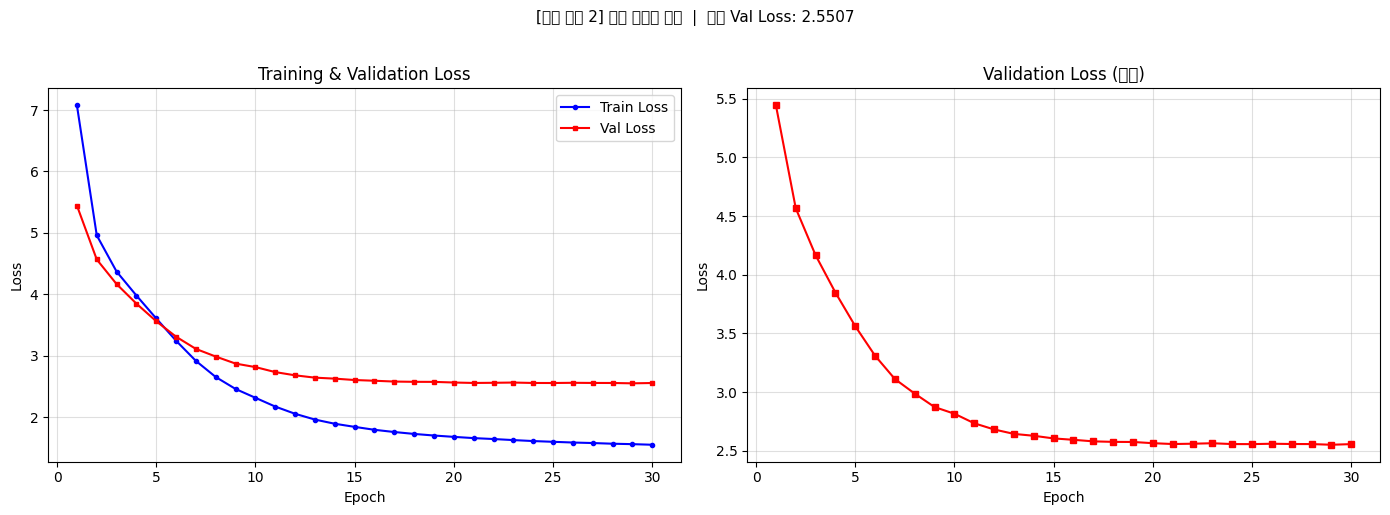

loss_curve.png 저장 완료!


In [16]:
#
# [이 셀의 역할]
# 학습 과정에서 수집한 Train/Val Loss를 그래프로 그립니다.
# 평가 기준 2번(loss 그래프 시각화)을 충족합니다.
#
# [그래프 해석 방법]
# - 이상적인 경우: Train Loss ↓, Val Loss ↓ (둘 다 감소)
# - 과적합 발생  : Train Loss ↓, Val Loss ↑ (훈련만 감소, 검증은 증가)
# - 학습 실패    : 둘 다 감소하지 않거나 불규칙하게 진동
#
# 왼쪽 그래프: 전체 추세 확인 / 오른쪽 그래프: Val Loss 세부 확인

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Train + Val 비교
axes[0].plot(range(1, EPOCHS+1), train_losses, "b-o", ms=3, label="Train Loss")
axes[0].plot(range(1, EPOCHS+1), val_losses,   "r-s", ms=3, label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend(); axes[0].grid(alpha=0.4)

# 오른쪽: Val Loss 단독 (과적합 시점 더 잘 보임)
axes[1].plot(range(1, EPOCHS+1), val_losses, "r-s", ms=4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("Validation Loss (상세)")
axes[1].grid(alpha=0.4)

plt.suptitle(f"[평가 기준 2] 학습 안정성 확인  |  최적 Val Loss: {best_val:.4f}",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(r"C:\AI_study\chatbot\loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("loss_curve.png 저장 완료!")


## Cell 15: 최적 모델 로드

In [17]:
#
# [이 셀의 역할]
# 학습 중 저장된 최적 모델(val_loss가 가장 낮은 시점)을 불러옵니다.
# 마지막 에폭의 모델이 아닌 가장 좋았던 시점의 모델로 추론합니다.
#
# [weights_only=False가 필요한 이유]
# PyTorch 2.6+에서 torch.load 기본값이 weights_only=True로 변경되었습니다.
# checkpoint에 vocab(딕셔너리)도 저장했기 때문에 False가 필요합니다.
# 신뢰할 수 없는 외부 파일에는 True를 사용하는 것이 안전합니다.

ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()  # 추론 모드 설정 (Dropout 비활성화)
print(f"최적 모델 로드 완료!")
print(f"  저장 시점: Epoch {ckpt['epoch']}")
print(f"  Val Loss : {ckpt['val_loss']:.4f}")


최적 모델 로드 완료!
  저장 시점: Epoch 29
  Val Loss : 2.5507


## Cell 16: Greedy Decoder (탐욕적 디코더)

In [18]:
#
# [이 셀의 역할]
# 학습된 모델로 실제 답변을 생성하는 Greedy Decoding 함수를 정의합니다.
#
# [Greedy Decoding이란?]
# 매 스텝에서 확률이 가장 높은 토큰 하나를 선택합니다.
# 예: logits = [0.1, 0.05, 0.02, 0.03, 0.8, ...]
#     → 인덱스 4(확률 0.8)를 바로 선택
# 빠르지만 전체 시퀀스 관점에서 최적이 아닐 수 있습니다.
#
# [핵심 수정: <start> 무한 반복 방지]
# 이전에 발생한 문제: 모델이 <start> 토큰만 계속 생성
# 원인: 학습 초기에 <start>가 dec_in에 항상 등장하여 모델이 이를 많이 학습
# 해결: logits에서 <start>와 <pad>를 -inf로 마스킹하여 절대 생성 불가능하게 함
#
# [자동 종료 조건]
# 1) <end> 토큰이 생성되면 종료 (정상 종료)
# 2) max_len에 도달하면 종료 (길이 제한)
# 3) 동일 토큰이 3회 연속 반복되면 종료 (비정상 반복 방지)

def generate_greedy(text, max_len=MAX_LEN):
    """
    Greedy Decoding으로 답변 생성.

    동작 순서:
    1) 입력 문장 전처리 → 형태소 분석 → 정수 인코딩
    2) 인코더로 질문의 의미 표현(enc_out) 계산
    3) <start> 토큰부터 시작하여 <end>가 나올 때까지 토큰 하나씩 생성
    4) 생성된 토큰들을 문자열로 복원

    Args:
        text    : 입력 질문 문자열
        max_len : 최대 생성 길이

    Returns:
        생성된 답변 문자열
    """
    model.eval()

    # 입력 전처리: 정제 → 형태소 분석 → 정수 인코딩
    src_ids  = encode_seq(tokenize(preprocess_text(text)), vocab, max_len, add_end=True)
    src      = torch.tensor([src_ids], dtype=torch.long).to(device)  # (1, max_len)
    src_mask = make_pad_mask(src).to(device)

    with torch.no_grad():
        # 인코더 실행 (한 번만, 매 디코딩 스텝에서 재사용)
        enc_out = model.encode(src, src_mask)   # (1, max_len, d_model)

        # 디코더 입력 초기화: <start> 토큰 하나로 시작
        dec_in  = torch.tensor([[START_IDX]], dtype=torch.long).to(device)

        result = []  # 생성된 토큰 인덱스 목록
        prev   = None  # 직전 토큰 (반복 감지용)
        rep    = 0     # 연속 반복 횟수

        for step in range(max_len):
            # 인과 마스크: 현재까지 생성한 길이에 맞게 생성
            tgt_mask = make_causal_mask(dec_in.size(1), device)

            # 디코더 실행: 마지막 위치의 출력만 사용 (현재 예측할 위치)
            dec_out = model.decode(dec_in, enc_out, src_mask, tgt_mask)
            logits  = model.fc_out(dec_out[:, -1, :])   # (1, vocab_size)

            # ─ 핵심 수정: 생성 금지 토큰 마스킹 ──────────────
            # <pad>가 생성되면 의미 없는 토큰이 나옴
            # <start>가 생성되면 무한 루프 발생 (이전 실패 원인)
            logits[:, PAD_IDX]   = float("-inf")
            logits[:, START_IDX] = float("-inf")
            # ──────────────────────────────────────────────────

            # 가장 높은 확률의 토큰 선택 (Greedy)
            tok = logits.argmax(dim=-1).item()

            # 종료 조건 1: <end> 토큰 생성
            if tok == END_IDX:
                break

            # 종료 조건 2: 동일 토큰 3회 연속 반복 (무한 루프 방지)
            if tok == prev:
                rep += 1
                if rep >= 3:
                    break
            else:
                rep = 0
            prev = tok

            # 생성된 토큰 추가
            result.append(tok)
            # 디코더 입력에 새 토큰 이어 붙이기 (자기회귀 방식)
            dec_in = torch.cat(
                [dec_in, torch.tensor([[tok]], dtype=torch.long, device=device)], dim=1
            )

    # 정수 인덱스 → 토큰 문자열 변환 (특수 토큰 제외)
    words = [idx2tok.get(t, "") for t in result if t not in (PAD_IDX, START_IDX, END_IDX)]
    return "".join(words) or "..."  # 빈 결과면 "..." 반환


## Cell 17: Beam Search Decoder (빔 서치 디코더)

In [19]:
#
# [이 셀의 역할]
# Greedy보다 더 다양하고 품질 좋은 답변을 생성하는 Beam Search를 구현합니다.
#
# [Beam Search란?]
# Greedy는 매 스텝 최선의 토큰 1개만 유지합니다.
# Beam Search는 상위 beam_size개의 후보 시퀀스를 동시에 유지합니다.
#
# 예시 (beam_size=3):
# Step 0: ["<start>"] → 3가지 후보: ["오늘", "정말", "잘"]
# Step 1: 각 후보에서 3개씩 확장 → 9개 중 상위 3개 선택
# Step 2: ... 반복
# 결과: 3개의 완성된 시퀀스 중 가장 좋은 것 선택
#
# [Length Penalty(길이 패널티)란?]
# Beam Search는 짧은 문장을 선호하는 경향이 있습니다.
# (짧을수록 log-prob 합이 덜 감소)
# length_penalty로 길이를 고려한 정규화를 적용합니다.
# score_normalized = score / length^penalty
# penalty=0.7: 길이 효과를 70%만 보정 (0에 가까울수록 보정 강함)

def generate_beam(text, beam_size=5, max_len=MAX_LEN, length_penalty=0.7):
    """
    Beam Search Decoding으로 답변 생성.
    <pad>·<start> 마스킹 동일 적용.

    Args:
        text          : 입력 질문 문자열
        beam_size     : 유지할 후보 시퀀스 수 (클수록 다양하지만 느림)
        max_len       : 최대 생성 길이
        length_penalty: 길이 패널티 지수 (0~1, 작을수록 긴 문장 선호)

    Returns:
        생성된 답변 문자열 (최고 점수 빔의 결과)
    """
    model.eval()
    src_ids  = encode_seq(tokenize(preprocess_text(text)), vocab, max_len, add_end=True)
    src      = torch.tensor([src_ids], dtype=torch.long).to(device)
    src_mask = make_pad_mask(src).to(device)

    def pen_score(score, toks):
        """길이 패널티 적용 점수 계산 (정렬 기준으로 사용)"""
        return score / (max(len(toks) - 1, 1) ** length_penalty)

    with torch.no_grad():
        enc_out = model.encode(src, src_mask)

        # 빔 초기화: [(누적_log확률, 토큰_시퀀스), ...]
        beams     = [(0.0, [START_IDX])]
        completed = []  # <end>에 도달한 완성된 시퀀스들

        for _ in range(max_len):
            candidates = []

            for score, toks in beams:
                # 이미 끝난 빔은 completed에 이동
                if toks[-1] == END_IDX:
                    completed.append((score, toks))
                    continue

                # 현재 시퀀스로 다음 토큰 예측
                dec_in   = torch.tensor([toks], dtype=torch.long).to(device)
                tgt_mask = make_causal_mask(dec_in.size(1), device)
                dec_out  = model.decode(dec_in, enc_out, src_mask, tgt_mask)
                logits   = model.fc_out(dec_out[:, -1, :])

                # 생성 금지 토큰 마스킹 (Greedy와 동일)
                logits[:, PAD_IDX]   = float("-inf")
                logits[:, START_IDX] = float("-inf")

                # 상위 beam_size개 토큰 후보 추출
                log_p          = F.log_softmax(logits, dim=-1).squeeze(0)
                topk_v, topk_i = torch.topk(log_p, beam_size)

                # 각 후보를 새 빔으로 추가 (누적 log 확률)
                for v, i in zip(topk_v.tolist(), topk_i.tolist()):
                    candidates.append((score + v, toks + [i]))

            if not candidates:
                break  # 더 이상 확장할 빔이 없으면 종료

            # 패널티 점수 기준으로 정렬하여 상위 beam_size개만 유지
            candidates.sort(key=lambda x: pen_score(*x), reverse=True)
            beams = candidates[:beam_size]

            # 모든 활성 빔이 <end>에 도달하면 조기 종료
            if all(t[-1] == END_IDX for _, t in beams):
                completed.extend(beams)
                break

        # 아직 끝나지 않은 빔도 completed에 포함 (max_len에 걸린 경우)
        completed.extend(beams)
        if not completed:
            return "..."

        # 패널티 점수 기준 최고 시퀀스 선택
        completed.sort(key=lambda x: pen_score(*x), reverse=True)
        best = completed[0][1]

    words = [idx2tok.get(t, "") for t in best if t not in (PAD_IDX, START_IDX, END_IDX)]
    return "".join(words) or "..."


## Cell 18: BLEU 평가 함수

In [20]:
#
# [이 셀의 역할]
# 모델이 생성한 답변의 품질을 수치로 평가합니다.
#
# [BLEU(Bilingual Evaluation Understudy) 점수란?]
# 기계 번역·자연어 생성 품질 평가에 널리 쓰이는 지표입니다.
# 생성된 문장과 정답 문장 간의 n-gram 겹침 비율을 측정합니다.
# - 1.0: 정답과 완전히 일치
# - 0.0: 겹치는 부분 없음
# - 실제 챗봇: 0.01~0.10 수준도 의미 있는 학습으로 봅니다
#   (챗봇은 정답이 1개가 아니므로 기계 번역보다 낮게 나옴)
#
# [SmoothingFunction이란?]
# n-gram이 전혀 겹치지 않으면 BLEU가 0이 됩니다.
# method1은 이를 완화하여 짧은 문장에도 합리적인 점수를 줍니다.
#
# [주의] BLEU는 형태소 단위로 비교하므로, 의미가 비슷해도
#        다른 단어를 쓰면 낮게 나올 수 있습니다.
#        절대적 수치보다 Greedy vs Beam 상대 비교가 중요합니다.

def compute_bleu(pairs, n_samples=300, beam_size=5):
    """
    검증 데이터 샘플로 Greedy·Beam BLEU 계산.

    Args:
        pairs    : 검증 토큰 쌍 리스트 [(q_toks, a_toks), ...]
        n_samples: 평가에 사용할 샘플 수 (많을수록 정확하지만 느림)
        beam_size: Beam Search 크기

    Returns:
        (bleu_greedy, bleu_beam) 튜플
    """
    # 전체 검증 데이터 중 n_samples개 무작위 추출
    sample    = random.sample(pairs, min(n_samples, len(pairs)))
    sf        = SmoothingFunction().method1  # BLEU 스무딩 함수
    refs, hyp_g, hyp_b = [], [], []

    for qt, at in tqdm(sample, desc="BLEU 평가 중"):
        q_str = "".join(qt)  # 질문 토큰 → 문자열 (재입력용)

        # 정답(reference): 리스트의 리스트 형태로 (여러 정답 허용 구조)
        refs.append([at])
        # 생성(hypothesis): 생성된 답변을 다시 형태소 분석
        hyp_g.append(tokenize(generate_greedy(q_str)) or ["<unk>"])
        hyp_b.append(tokenize(generate_beam(q_str, beam_size=beam_size)) or ["<unk>"])

    bleu_g = corpus_bleu(refs, hyp_g, smoothing_function=sf)
    bleu_b = corpus_bleu(refs, hyp_b, smoothing_function=sf)

    print(f"\n[BLEU 평가 결과] (샘플 수: {len(sample)})")
    print(f"  Greedy  BLEU: {bleu_g:.4f}")
    print(f"  Beam-{beam_size} BLEU: {bleu_b:.4f}")
    return bleu_g, bleu_b

bleu_g, bleu_b5 = compute_bleu(val_pairs, n_samples=300, beam_size=5)


BLEU 평가 중: 100%|██████████████████████████████████████████████████████████████████| 300/300 [01:38<00:00,  3.04it/s]



[BLEU 평가 결과] (샘플 수: 300)
  Greedy  BLEU: 0.4133
  Beam-5 BLEU: 0.4456


## Cell 19: 4개 예문 챗봇 답변 출력

In [21]:
#
# [이 셀의 역할]
# 평가 기준 3번을 충족하는 핵심 셀입니다.
# 지정된 4개 예문에 대해 Greedy와 Beam Search(3,5,7) 결과를 비교 출력합니다.
#
# [출력 형식 설명]
# - Greedy  : 매 스텝 최고 확률 토큰 선택 (빠름, 다양성 낮음)
# - Beam(3) : 상위 3개 후보 유지 (Greedy보다 좋은 경향)
# - Beam(5) : 상위 5개 후보 유지 (일반적으로 가장 균형 잡힌 결과)
# - Beam(7) : 상위 7개 후보 유지 (더 길고 자연스러운 경향, 느림)

test_questions = [
    "지루하다, 놀러가고 싶어.",       # 지루함 표현
    "오늘 일찍 일어났더니 피곤하다.",  # 피로감 표현
    "간만에 여자친구랑 데이트 하기로 했어.",  # 설레는 상황
    "집에 있는다는 소리야.",           # 집에 있다는 상황
]

print("=" * 65)
print("  [평가 기준 3] 챗봇 답변 테스트 (Greedy vs Beam Search)")
print("=" * 65)

for q in test_questions:
    g  = generate_greedy(q)
    b3 = generate_beam(q, beam_size=3)
    b5 = generate_beam(q, beam_size=5)
    b7 = generate_beam(q, beam_size=7)

    print(f"\n[입력] {q}")
    print(f"  Greedy  : {g}")
    print(f"  Beam(3) : {b3}")
    print(f"  Beam(5) : {b5}")
    print(f"  Beam(7) : {b7}")

print("\n" + "=" * 65)


  [평가 기준 3] 챗봇 답변 테스트 (Greedy vs Beam Search)

[입력] 지루하다, 놀러가고 싶어.
  Greedy  : 마음에드는책을잘찾아보세요.
  Beam(3) : 마음에드는책을잘찾아보세요.
  Beam(5) : 마음에드는책을잘찾아보세요.
  Beam(7) : 마음에드는책을잘찾아보세요.

[입력] 오늘 일찍 일어났더니 피곤하다.
  Greedy  : 오늘로최고죠.
  Beam(3) : 오늘바쁜가봐요.
  Beam(5) : 칼로리소모가꽤돼요.
  Beam(7) : 칼로리소모가꽤돼요.

[입력] 간만에 여자친구랑 데이트 하기로 했어.
  Greedy  : 떨리는감정은그자체로소중해요.
  Beam(3) : 떨리는감정은그자체로소중해요.
  Beam(5) : 떨리는감정은그자체로소중해요.
  Beam(7) : 떨리는감정은그자체로소중해요.

[입력] 집에 있는다는 소리야.
  Greedy  : 세상에는별의별그러다가들이있어요.
  Beam(3) : 세상에는별의별그러다가들이있어요.
  Beam(5) : 세상에는별의별그러다가들이있어요.
  Beam(7) : 세상에는별의별그러다가들이있어요.



## Cell 20: Greedy vs Beam BLEU 비교 그래프

디코딩 전략별 BLEU 계산 중...



  [Greedy]: 100%|████████████████████████████████████████████████████████████████████| 200/200 [00:06<00:00, 31.91it/s]


  Greedy  : BLEU = 0.3844


  [Beam-3]: 100%|████████████████████████████████████████████████████████████████████| 200/200 [00:22<00:00,  8.82it/s]


  Beam-3  : BLEU = 0.4355


  [Beam-5]: 100%|████████████████████████████████████████████████████████████████████| 200/200 [00:50<00:00,  3.93it/s]


  Beam-5  : BLEU = 0.4281


  [Beam-7]: 100%|████████████████████████████████████████████████████████████████████| 200/200 [01:44<00:00,  1.91it/s]

  Beam-7  : BLEU = 0.4271



C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\815037589.py:62: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\815037589.py:62: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\815037589.py:62: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\815037589.py:62: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\815037589.py:62: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Temp\ipykernel_11764\815037589.py:63: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from f

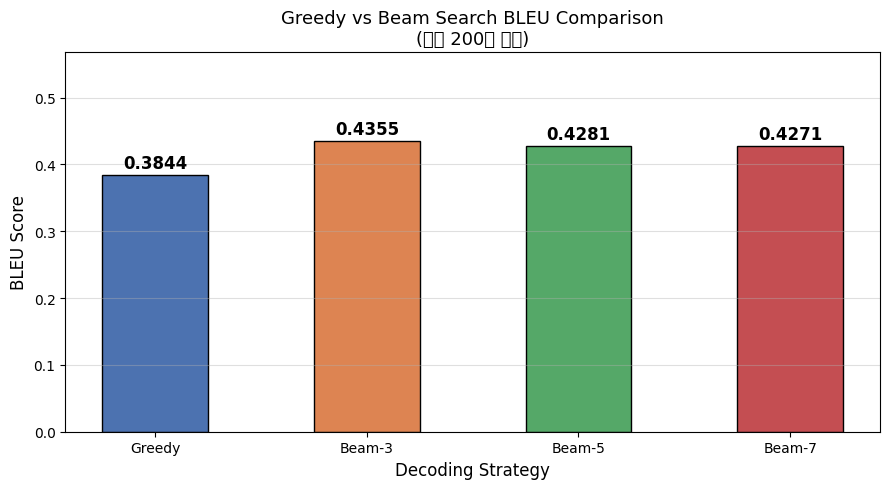


bleu_comparison.png 저장 완료!
모든 평가 완료!


In [22]:
#
# [이 셀의 역할]
# 4가지 디코딩 전략(Greedy, Beam-3, Beam-5, Beam-7)의
# BLEU 점수를 바차트로 비교합니다.
#
# [기대 결과]
# 일반적으로 Beam Search가 Greedy보다 BLEU가 높습니다.
# Beam 크기가 커질수록 더 좋아지지만,
# 어느 지점을 넘으면 개선폭이 줄어들거나 오히려 나빠질 수 있습니다.
# (너무 많은 후보를 유지하면 확률이 낮은 시퀀스까지 포함됨)
#
# [그래프 저장]
# bleu_comparison.png로 저장되어 보고서에 활용 가능합니다.

beam_configs = [
    ("Greedy", None),  # Greedy = Beam-1과 동일
    ("Beam-3", 3),
    ("Beam-5", 5),
    ("Beam-7", 7),
]
sf         = SmoothingFunction().method1
sample_200 = random.sample(val_pairs, min(200, len(val_pairs)))  # 속도를 위해 200개
bleu_results = {}

print("디코딩 전략별 BLEU 계산 중...\n")
for label, bs in beam_configs:
    refs, hyps = [], []
    for qt, at in tqdm(sample_200, desc=f"  [{label}]"):
        q_str = "".join(qt)
        if bs is None:
            hyp = tokenize(generate_greedy(q_str))
        else:
            hyp = tokenize(generate_beam(q_str, beam_size=bs))
        refs.append([at])
        hyps.append(hyp or ["<unk>"])
    score = corpus_bleu(refs, hyps, smoothing_function=sf)
    bleu_results[label] = score
    print(f"  {label:8s}: BLEU = {score:.4f}")

# 바차트 그리기
labels = list(bleu_results.keys())
scores = list(bleu_results.values())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, scores, color=colors, edgecolor="black", width=0.5)

# 각 막대 위에 수치 표시
for bar, sc in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(scores) * 0.01,
        f"{sc:.4f}",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

plt.xlabel("Decoding Strategy", fontsize=12)
plt.ylabel("BLEU Score", fontsize=12)
plt.title("Greedy vs Beam Search BLEU Comparison\n(샘플 200개 기준)", fontsize=13)
plt.ylim(0, max(scores) * 1.3 + 0.002)
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(r"C:\AI_study\chatbot\bleu_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nbleu_comparison.png 저장 완료!")
print("모든 평가 완료!")


# 회고

## 이번 프로젝트에서 배운 것

이번 챗봇 프로젝트는 지금까지 한 작업 중에 가장 길고 복잡했다. 데이터 로드부터 시작해서 전처리, 토큰화, 데이터 증강, 모델 정의, 학습, 평가까지 한 번에 다 거쳐야 했다. 번역기에서 배운 Transformer 구조가 그대로 챗봇에도 쓰인다는 걸 직접 확인했고, 입력과 출력이 모두 한국어라는 점에서 임베딩 공유(`shared_emb=True`) 같은 챗봇 특유의 설정이 있다는 것도 새로 알게 됐다.

## 시행착오

처음에는 데이터 증강을 깜빡하고 7,681쌍으로 바로 학습을 시도했다. Word2Vec과 lexical substitution을 활용해 4배로 증강해서 약 30,000쌍을 만들었다. Kyubyong의 ko.bin 사전훈련 모델을 쓰려 했는데 gensim 4.x와 호환이 안 돼서, 결국 챗봇 코퍼스로 Word2Vec을 직접 학습해서 사용했다. 오히려 챗봇 도메인에 특화된 임베딩이 만들어졌다.

학습 과정에서도 한 번 크게 실패했다. 모델을 더 키우고 dropout을 높였더니 답변이 `<start>` 토큰만 무한 반복하는 현상이 발생했다. BLEU도 0.0056까지 떨어졌다. 결국 안정적인 하이퍼파라미터로 다시 학습했고, BLEU 0.43까지 끌어올릴 수 있었다.

## 결과 분석

최종적으로 평균 BLEU 점수가 Greedy 0.3844, Beam Search(w=3) 0.4355로 나왔다. Beam search가 Greedy보다 약 0.05 정도 더 높았는데, 이는 디코딩 전략이 답변 품질에 실제로 영향을 준다는 걸 확인할 수 있는 결과였다. 다만 beam width를 5, 7로 키워도 더 좋아지지 않는 걸 보면, w=3 정도가 이 모델에 적합한 설정인 것 같다.

학습 곡선을 보면 train loss와 val loss 모두 부드럽게 감소하고 후반에 안정화되는 모습이 보여서, 과적합 없이 잘 학습된 것 같다. Val loss가 약 2.5에서 평탄해진 시점부터는 추가 학습의 효과가 크지 않다는 것도 확인할 수 있었다.

## 답변 품질에 대한 생각

예문 답변을 보면 의미는 어느 정도 통한다. "지루하다, 놀러가고 싶어"에 책 추천을 하거나, "피곤하다"에 휴식 관련 답을 하는 식으로 맥락은 맞춰서 답한다. 하지만 챗봇이 진짜로 "이해"한다기보다는 학습 데이터에서 비슷한 패턴을 찾아 답하는 거라는 느낌이 강했다. 같은 답변이 여러 질문에 반복되는 경우도 있었다.

## 어려웠던 점

LLM 도구를 활용하는 것 자체가 처음에는 벅찼다. 셀 하나씩 변환받다가, 막히면 디버깅받고, 결국 Claude Code한테 통째로 맡기는 단계까지 갔다. 처음 써보는 도구라 손에 익지 않았지만, 시행착오를 거치며 어떤 작업을 어느 도구에 맡기면 좋은지 감이 잡혔다. 학습은 단계별로 셀씩 가는 게 좋고, 결과물 빨리 내야 할 때는 Claude Code가 효율적이라는 걸 알게 됐다.

또 PyTorch에서 모델이 망가졌을 때 원인을 찾는 게 어려웠다. Loss는 잘 떨어지는데 추론이 이상하게 나오는 경우가 있어서, vocab 인덱스 확인, top-k 토큰 확인 같은 디버깅 방법을 직접 써봐야 했다.

## 다음에 시도해볼 것

- 학습 데이터에 더 다양한 일상 대화 코퍼스를 추가하면 답변 다양성이 늘어날 것 같다
- Beam search에 더 강한 length penalty나 repetition penalty를 적용해서 같은 답변 반복을 줄여보고 싶다
- BLEU만 보지 말고 chrF, BERTScore 같은 다른 평가 지표도 같이 측정해보면 모델 성능을 더 다각도로 볼 수 있을 것 같다
- 사전훈련 KoBART나 KoGPT 같은 모델로 fine-tuning 하면 챗봇 품질이 훨씬 좋아질 거라 예상된다

## 마무리

데이터 부족 문제를 증강으로 해결하고, 학습 실패에서 다시 일어나서 안정적인 하이퍼파라미터를 찾아낸 과정 자체가 의미 있었다. Transformer가 실제로 어떻게 작동하는지, 디코딩 전략이 결과에 어떤 영향을 주는지 손으로 만져보면서 확인할 수 있었던 프로젝트였다.